In [30]:
# ===================== 1) CONFIG =====================
RAW_PATH = r"C:/Users/admin/Documents/PSM1_LAVEN/Datasets/Final_dataset_CVD19_ready_hardneg_bulk.csv"
OUT_DIR  = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/Logistic Regression + TF-IDF/outputs_lr_tfidf"
SEED     = 42

# ===================== 2) IMPORTS =====================
import os, json, re, unicodedata, warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, average_precision_score, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore", category=UserWarning)
os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED)

# ===================== 3) HELPERS =====================
def normalize_negation(s: str) -> str:
    """Expand contractions, mark negation scopes lightly."""
    s = str(s)
    s = re.sub(r"\b(can|do|does|did|is|are|was|were|has|have|had|should|would|could|may|might|must)n[’']?t\b",
               r"\1 not", s, flags=re.I)
    s = re.sub(r"\bwon[’']?t\b", "will not", s, flags=re.I)
    s = re.sub(r"\bain[’']?t\b", "is not", s, flags=re.I)
    s = re.sub(r"\bnot\s+([a-z]+)\b", r"not_\1", s, flags=re.I)
    return s

def eval_metrics(y_true, proba, thr):
    preds = (proba >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)
    p_pc, r_pc, f1_pc, _ = precision_recall_fscore_support(y_true, preds, average=None, zero_division=0)
    cm = confusion_matrix(y_true, preds).tolist()
    try:  roc = roc_auc_score(y_true, proba)
    except: roc = float("nan")
    try:  pr_auc = average_precision_score(y_true, proba)
    except: pr_auc = float("nan")
    return {
        "threshold": float(thr),
        "accuracy": float(acc),
        "macro_precision": float(prec),
        "macro_recall": float(rec),
        "macro_f1": float(f1),
        "per_class_precision_[fake,real]": [float(x) for x in p_pc],
        "per_class_recall_[fake,real]": [float(x) for x in r_pc],
        "per_class_f1_[fake,real]": [float(x) for x in f1_pc],
        "confusion_matrix_[[tn,fp],[fn,tp]]": cm,
        "roc_auc": float(roc),
        "pr_auc": float(pr_auc)
    }, preds

def tune_threshold(y_val, proba):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.linspace(0.10, 0.90, 81):
        _, _, f1, _ = precision_recall_fscore_support(
            y_val, (proba >= thr).astype(int), average="macro", zero_division=0
        )
        if f1 > best_f1:
            best_f1, best_thr = float(f1), float(thr)
    return best_thr, best_f1

# Plotting helpers
def save_confusion(y_true, proba, thr, title, path):
    preds = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["fake", "real"])
    fig, ax = plt.subplots(figsize=(4,4), dpi=160)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout(); plt.savefig(path); plt.close(fig)

def save_roc_pr(y_true, proba, title_prefix, out_dir):
    try:
        fpr, tpr, _ = roc_curve(y_true, proba)
        precision, recall, _ = precision_recall_curve(y_true, proba)
    except Exception:
        return
    fig = plt.figure(figsize=(10,4), dpi=160)
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr); plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{title_prefix} ROC")
    plt.subplot(1,2,2)
    plt.plot(recall, precision)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{title_prefix} PR")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{title_prefix.lower()}_roc_pr.png"))
    plt.close(fig)

# Sklearn helper transformers to build multi-view features from a single text column (Series)
def _identity(X): return X
def _negview(X):  return X.apply(normalize_negation)

pick_raw = FunctionTransformer(_identity, validate=False)
pick_neg = FunctionTransformer(_negview,  validate=False)

# ===================== 4) LOAD & CLEAN =====================
df = pd.read_csv(RAW_PATH, encoding="latin1")
need = {"claim_id","text","label"}
assert need.issubset(df.columns), f"Missing cols: {need - set(df.columns)}"

df["text_clean"] = df["text"].astype(str).apply(lambda x: unicodedata.normalize("NFKC", x))
before = len(df)
df = df.drop_duplicates(subset=["text_clean","label"]).reset_index(drop=True)
print(f"Removed duplicates: {before - len(df)} | Remaining: {len(df)}")

df["claim_id"] = pd.to_numeric(df["claim_id"], errors="coerce").astype("Int64")
df = df.dropna(subset=["claim_id"]).reset_index(drop=True)

# ===================== 5) GROUPED SPLITS =====================
groups = df["claim_id"]
gss1 = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=SEED)
tr_idx, te_idx = next(gss1.split(df, groups=groups))
train_df, test_df = df.iloc[tr_idx].copy(), df.iloc[te_idx].copy()

gss2 = GroupShuffleSplit(test_size=0.10, n_splits=1, random_state=SEED)
tr2_idx, va_idx = next(gss2.split(train_df, groups=train_df["claim_id"]))
final_train, final_val = train_df.iloc[tr2_idx].copy(), train_df.iloc[va_idx].copy()

for name, split in [("train", final_train), ("val", final_val), ("test", test_df)]:
    split.to_csv(os.path.join(OUT_DIR, f"{name}_clean.csv"), index=False, encoding="utf-8")

print({"train": len(final_train), "val": len(final_val), "test": len(test_df)})

# ===================== 6) LABELS =====================
labmap = {"fake":0, "real":1}
for s in (final_train, final_val, test_df):
    s["label_id"] = s["label"].str.lower().map(labmap).astype(int)

y_train = final_train["label_id"].values
y_val   = final_val["label_id"].values
y_test  = test_df["label_id"].values

# ===================== 7) SMALL GRID OF MODELS =====================
classes = np.array([0,1])
cw_vals = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw_vals)}
print("Class weights:", class_weight)

grid = []
for C in [0.5, 1.0, 2.0]:
    for word_ng_max in [2, 3]:
        for char_ng_max in [5, 6]:
            for min_df in [2, 3]:
                grid.append(dict(C=C, word_ng_max=word_ng_max, char_ng_max=char_ng_max, min_df=min_df))

best = None
best_name = None

for hp in grid:
    word_raw = Pipeline([
        ("pick", pick_raw),
        ("tfidf", TfidfVectorizer(
            analyzer="word", ngram_range=(1, hp["word_ng_max"]),
            min_df=hp["min_df"], max_features=120_000, sublinear_tf=True,
            lowercase=True, strip_accents="unicode"
        ))
    ])
    word_neg = Pipeline([
        ("pick", pick_neg),
        ("tfidf", TfidfVectorizer(
            analyzer="word", ngram_range=(1, hp["word_ng_max"]),
            min_df=hp["min_df"], max_features=120_000, sublinear_tf=True,
            lowercase=True, strip_accents="unicode"
        ))
    ])
    char_v = Pipeline([
        ("pick", pick_raw),
        ("tfidf", TfidfVectorizer(
            analyzer="char", ngram_range=(3, hp["char_ng_max"]),
            min_df=hp["min_df"], max_features=120_000, sublinear_tf=True,
            lowercase=True
        ))
    ])

    feats = FeatureUnion([
        ("word_raw", word_raw),
        ("word_neg", word_neg),
        ("char_v",   char_v),
    ])

    lr = LogisticRegression(
        solver="saga", penalty="l2", C=hp["C"], max_iter=1000,
        class_weight=class_weight, n_jobs=-1, random_state=SEED
    )

    pipe = Pipeline([("feats", feats), ("clf", lr)])
    pipe.fit(final_train["text_clean"], y_train)

    # threshold tuning on val for this candidate
    val_proba = pipe.predict_proba(final_val["text_clean"])[:, 1]
    thr, f1 = tune_threshold(y_val, val_proba)

    if (best is None) or (f1 > best["val_macro_f1"]):
        best = {
            "hp": hp, "pipe": pipe,
            "val_thr": thr, "val_macro_f1": f1,
            "val_proba": val_proba
        }
        best_name = f"C={hp['C']} | word_ng=1-{hp['word_ng_max']} | char_ng=3-{hp['char_ng_max']} | min_df={hp['min_df']}"

print("Best (val macro-F1):", best["val_macro_f1"], "|", best_name)
best_pipe = best["pipe"]
best_thr  = best["val_thr"]

# ===================== 8) TRAIN / VAL / TEST EVAL =====================
# TRAIN
train_proba = best_pipe.predict_proba(final_train["text_clean"])[:, 1]
train_metrics, train_preds = eval_metrics(y_train, train_proba, best_thr)

# VAL
val_metrics, val_preds = eval_metrics(y_val, best["val_proba"], best_thr)

# TEST
test_proba = best_pipe.predict_proba(test_df["text_clean"])[:, 1]
test_metrics, test_preds = eval_metrics(y_test, test_proba, best_thr)

# Print quick summary
print("TRAIN:", {k:v for k,v in train_metrics.items() if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})
print("VAL  :", {k:v for k,v in val_metrics.items()   if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})
print("TEST :", {k:v for k,v in test_metrics.items()  if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})

# ===================== 9) DIAGNOSTICS =====================
# Negation subset (optional)
neg_report = None
if "variant" in test_df.columns:
    m = test_df["variant"].astype(str).str.contains("neg", case=False, na=False)
    if m.any():
        neg_metrics, _ = eval_metrics(y_test[m.values], test_proba[m.values], best_thr)
        neg_report = {k: neg_metrics[k] for k in ["accuracy","macro_f1","roc_auc","pr_auc"]}
        print("NEGATION subset (test, global thr):", neg_report, f"| n={int(m.sum())}")

# Paraphrase/variant consistency
test_eval = test_df.copy()
test_eval["pred"] = test_preds
multi = test_eval.groupby("claim_id").filter(lambda g: len(g)>1).groupby("claim_id")
multi_total = len(list(multi.groups.keys()))
consistent = sum(1 for _, g in multi if g["pred"].nunique()==1)
para_consistency = float(consistent/multi_total) if multi_total>0 else float("nan")
print(f"Paraphrase consistency (test): {para_consistency:.3f} over {multi_total} multi-variant claims")

# ===================== 10) PLOTS (Train / Val / Test) =====================
save_confusion(y_train, train_proba, best_thr, "Train Confusion Matrix", os.path.join(OUT_DIR, "cm_train.png"))
save_confusion(y_val,   best["val_proba"], best_thr, "Val Confusion Matrix",   os.path.join(OUT_DIR, "cm_val.png"))
save_confusion(y_test,  test_proba,  best_thr, "Test Confusion Matrix",  os.path.join(OUT_DIR, "cm_test.png"))

save_roc_pr(y_train, train_proba, "Train", OUT_DIR)
save_roc_pr(y_val,   best["val_proba"], "Val", OUT_DIR)
save_roc_pr(y_test,  test_proba,  "Test", OUT_DIR)

# ===================== 11) SAVE ARTIFACTS =====================
model_path = os.path.join(OUT_DIR, "lr_tfidf_negaware.joblib")
joblib.dump(best_pipe, model_path)

metrics = {
    "best_hyperparams": best["hp"],
    "best_threshold": float(best_thr),
    "train": train_metrics,                 # <-- added
    "val": val_metrics,
    "test": test_metrics,
    "paraphrase_consistency_test": float(para_consistency),
}
if neg_report is not None:
    metrics["negation_test_subset"] = neg_report

with open(os.path.join(OUT_DIR, "lr_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

preds_out = pd.DataFrame({
    "claim_id": test_df["claim_id"],
    "text_clean": test_df["text_clean"],
    "true_label": test_df["label"],
    "proba_real": test_proba,
    "pred_label": np.where(test_preds==1, "real", "fake")
})
preds_out.to_csv(os.path.join(OUT_DIR, "test_predictions.csv"), index=False, encoding="utf-8")

print("Saved:", {
    "model_path": model_path,
    "metrics_json": os.path.join(OUT_DIR, "lr_metrics.json"),
    "test_predictions": os.path.join(OUT_DIR, "test_predictions.csv"),
    "plots": {
        "cm_train": os.path.join(OUT_DIR, "cm_train.png"),
        "cm_val":   os.path.join(OUT_DIR, "cm_val.png"),
        "cm_test":  os.path.join(OUT_DIR, "cm_test.png"),
        "rocpr_train": os.path.join(OUT_DIR, "train_roc_pr.png"),
        "rocpr_val":   os.path.join(OUT_DIR, "val_roc_pr.png"),
        "rocpr_test":  os.path.join(OUT_DIR, "test_roc_pr.png"),
    },
    "splits": {
        "train": os.path.join(OUT_DIR, "train_clean.csv"),
        "val":   os.path.join(OUT_DIR, "val_clean.csv"),
        "test":  os.path.join(OUT_DIR, "test_clean.csv"),
    }
})


Removed duplicates: 0 | Remaining: 24537
{'train': 17668, 'val': 1941, 'test': 4928}
Class weights: {0: 0.9626239511823036, 1: 1.0403957131079966}
Best (val macro-F1): 0.8037042178638157 | C=1.0 | word_ng=1-3 | char_ng=3-5 | min_df=3
TRAIN: {'accuracy': 0.8719719266470455, 'macro_precision': 0.875648489633762, 'macro_recall': 0.8740191638277025, 'macro_f1': 0.871926703584064, 'roc_auc': 0.9529144673012172, 'pr_auc': 0.9489039844003255}
VAL  : {'accuracy': 0.80370942812983, 'macro_precision': 0.8075035347256136, 'macro_recall': 0.8079533950973232, 'macro_f1': 0.8037042178638157, 'roc_auc': 0.8662885437623069, 'pr_auc': 0.832440260068181}
TEST : {'accuracy': 0.7922077922077922, 'macro_precision': 0.7939822088206017, 'macro_recall': 0.7943140364789849, 'macro_f1': 0.7922010838233599, 'roc_auc': 0.8659566646841131, 'pr_auc': 0.844469692712678}
NEGATION subset (test, global thr): {'accuracy': 0.45367717287488063, 'macro_f1': 0.45022215694194545, 'roc_auc': 0.43512210325608686, 'pr_auc': 0.4

In [29]:
# ====== CONFIG ======
OUT_DIR = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/Logistic Regression + TF-IDF/outputs_lr_tfidf"

# ====== IMPORTS ======
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report,
    average_precision_score, log_loss
)
from sklearn.calibration import calibration_curve
import joblib

os.makedirs(os.path.join(OUT_DIR, "plots"), exist_ok=True)
PLOT_DIR = os.path.join(OUT_DIR, "plots")

# ====== LOAD ARTIFACTS ======
pipe = joblib.load(os.path.join(OUT_DIR, "lr_tfidf_pipeline.joblib"))

# splits saved by your old training script
train_df = pd.read_csv(os.path.join(OUT_DIR, "train_clean.csv"))
val_df   = pd.read_csv(os.path.join(OUT_DIR, "val_clean.csv"))
test_df  = pd.read_csv(os.path.join(OUT_DIR, "test_clean.csv"))

label_map = {"fake":0, "real":1}
y_train = train_df["label"].map(label_map).values
y_val   = val_df["label"].map(label_map).values
y_test  = test_df["label"].map(label_map).values

# best threshold chosen on val by the old script (fallback 0.5 if missing)
thr = 0.5
metrics_json = os.path.join(OUT_DIR, "lr_metrics.json")
if os.path.exists(metrics_json):
    with open(metrics_json, "r") as f:
        meta = json.load(f)
    thr = float(meta.get("best_threshold", 0.5))

# ====== PROBABILITIES ======
p_train = pipe.predict_proba(train_df["text_clean"])[:, 1]
p_val   = pipe.predict_proba(val_df["text_clean"])[:, 1]
p_test  = pipe.predict_proba(test_df["text_clean"])[:, 1]

# ====== METRICS TABLE ======
def split_report(name, y, p, thr):
    pred = (p >= thr).astype(int)
    acc  = accuracy_score(y, pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
    try:
        roc = roc_auc_score(y, p)
        prauc = average_precision_score(y, p)
    except Exception:
        roc, prauc = float("nan"), float("nan")
    ll = log_loss(y, np.clip(p, 1e-7, 1-1e-7))
    print(f"{name:5s} | acc={acc:.4f}  prec={pr:.4f}  rec={rc:.4f}  f1={f1:.4f}  roc_auc={roc:.4f}  pr_auc={prauc:.4f}  logloss={ll:.4f}")
    return {"acc":acc,"prec":pr,"rec":rc,"f1":f1,"roc":roc,"pr_auc":prauc,"logloss":ll,"pred":pred}

print("=== METRICS @ threshold =", thr, "===")
m_tr = split_report("train", y_train, p_train, thr)
m_va = split_report("val",   y_val,   p_val,   thr)
m_te = split_report("test",  y_test,  p_test,  thr)
print("\nClassification report (TEST):\n",
      classification_report(y_test, m_te["pred"], target_names=["fake","real"], zero_division=0))

# ====== HELPERS ======
def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()

# ----- ROC CURVES -----
plt.figure(figsize=(6,5))
for name, y, p in [("train", y_train, p_train), ("val", y_val, p_val), ("test", y_test, p_test)]:
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC curves")
plt.legend()
savefig(os.path.join(PLOT_DIR, "roc_curves.png"))

# ----- PRECISION–RECALL CURVES -----
plt.figure(figsize=(6,5))
for name, y, p in [("train", y_train, p_train), ("val", y_val, p_val), ("test", y_test, p_test)]:
    prec, rec, _ = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall curves")
plt.legend()
savefig(os.path.join(PLOT_DIR, "pr_curves.png"))

# ----- CONFUSION MATRICES (VAL & TEST) -----
def plot_cm(y, p, title, fname):
    pred = (p >= thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0,1])
    plt.figure(figsize=(4.6,4))
    plt.imshow(cm)
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center", fontsize=11)
    plt.xticks([0,1], ["fake","real"]); plt.yticks([0,1], ["fake","real"])
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    savefig(os.path.join(PLOT_DIR, fname))

plot_cm(y_val,  p_val,  f"Confusion Matrix (VAL, thr={thr:.2f})",  "cm_val.png")
plot_cm(y_test, p_test, f"Confusion Matrix (TEST, thr={thr:.2f})", "cm_test.png")

# ----- ACCURACY & LOG LOSS (bars) -----
plt.figure(figsize=(6,4))
plt.bar(["train","val","test"], [m_tr["acc"], m_va["acc"], m_te["acc"]])
plt.ylim(0,1); plt.ylabel("Accuracy"); plt.title("Accuracy by split")
savefig(os.path.join(PLOT_DIR, "accuracy_bars.png"))

plt.figure(figsize=(6,4))
plt.bar(["train","val","test"], [m_tr["logloss"], m_va["logloss"], m_te["logloss"]])
plt.ylabel("Log loss"); plt.title("Log loss by split")
savefig(os.path.join(PLOT_DIR, "logloss_bars.png"))

# ----- CALIBRATION (RELIABILITY) CURVES -----
plt.figure(figsize=(6,5))
for name, y, p in [("val", y_val, p_val), ("test", y_test, p_test)]:
    prob_true, prob_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o", label=f"{name}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Predicted probability (bin mean)"); plt.ylabel("Empirical fraction of positives")
plt.title("Calibration (Reliability)"); plt.legend()
savefig(os.path.join(PLOT_DIR, "calibration.png"))

# ----- THRESHOLD SWEEP (F1 on VAL) -----
ths = np.linspace(0.05, 0.95, 91)
f1s = []
for t in ths:
    _, _, f1, _ = precision_recall_fscore_support(y_val, (p_val>=t).astype(int),
                                                  average="macro", zero_division=0)
    f1s.append(f1)
best_idx = int(np.argmax(f1s))
plt.figure(figsize=(6,4))
plt.plot(ths, f1s)
plt.axvline(thr, linestyle="--")
plt.scatter([ths[best_idx]],[f1s[best_idx]])
plt.xlabel("Threshold"); plt.ylabel("Macro F1"); plt.title("Val F1 vs Threshold")
savefig(os.path.join(PLOT_DIR, "threshold_sweep_val.png"))

print("\nSaved plots to:", PLOT_DIR)


=== METRICS @ threshold = 0.42000000000000004 ===
train | acc=0.8509  prec=0.8558  rec=0.8533  f1=0.8508  roc_auc=0.9380  pr_auc=0.9308  logloss=0.3679
val   | acc=0.7970  prec=0.8026  rec=0.8020  f1=0.7970  roc_auc=0.8623  pr_auc=0.8177  logloss=0.4659
test  | acc=0.7900  prec=0.7932  rec=0.7928  f1=0.7900  roc_auc=0.8611  pr_auc=0.8300  logloss=0.4673

Classification report (TEST):
               precision    recall  f1-score   support

        fake       0.84      0.74      0.79      2600
        real       0.75      0.84      0.79      2328

    accuracy                           0.79      4928
   macro avg       0.79      0.79      0.79      4928
weighted avg       0.80      0.79      0.79      4928


Saved plots to: C:/Users/admin/Documents/PSM1_LAVEN/Model/Logistic Regression + TF-IDF/outputs_lr_tfidf\plots


=== 10 random examples ===


,claim_id,text_short,label,pred_label,proba_real,correct
1665,3562,False image and note spread claiming to be written by a university president that the heat from a hair dryer can kill coronavirus germs,fake,fake,0.033548,True
3592,11656,"n.b. covid-19 roundup: no new cases for 9th straight day, but province isn't ready to 'declare victory'",real,real,0.947136,True
2726,8063,spraying with boiling water eliminates the new coronavirus.,fake,fake,0.098376,True
2380,6505,"a message of key takeaways from an interview of hdfc bank md & ceo aditya puri, where he has said how india will survive the coronavirus pandemic.",fake,fake,0.045629,True
676,519,"As a point of comparison, cigarettes are approved by the FDA.",fake,fake,0.262678,True
290,218,"Individual studies on sun exposure and health undergo peer review; alleging they are a ""cover-upÂ for vaccine side effects conflates unrelated research topics without evidence.",real,real,0.912677,True
577,430,Reports suggest the UK's Prime Minister's booster was not a fake.,real,fake,0.285448,False
2561,7297,"a french doctor is not quoted as saying that us billionaire bill gates wants to sell a covid-19 vaccine in africa, but it's poisonous and will destroy africa.",real,fake,0.177155,False
1519,2968,It is not true that Cebu City looking for own quarantine facility for residents with suspected 2019-nCov,fake,real,0.644111,False
2194,5727,"coronavirus outbreak updates: maharashtras cases sur..est positive; toll mounts to 5,984 with 160 fatalities",real,real,0.777914,True



=== 5 most confident REAL (highest proba_real) ===


,claim_id,text_short,label,pred_label,proba_real,correct
4349,14316,Pfizer boosters lower severe illness risk in seniors above 65.,real,real,0.993086,True
4203,14177,Masks remained recommended in long-term care homes across Canada in 2025.,real,real,0.992654,True
4202,14177,"In 2025, Canada reminded visitors to senior centers to wear masks.",real,real,0.990689,True
4601,14585,"In April 2022, Canada removed border testing for incoming travelers.",real,real,0.986371,True
4602,14585,Travelers entering Canada no longer needed COVID-19 tests after April 2022.,real,real,0.984139,True



=== 5 most confident FAKE (lowest proba_real) ===


,claim_id,text_short,label,pred_label,proba_real,correct
2874,8635,It is not false that tea can cure coronavirus.,fake,fake,0.003186,True
1995,4878,"It is not false that no, this is the italian president crying over covid-19 deaths",fake,fake,0.004440,True
2769,8223,video shows the suicide of an american man because he is infected with coronavirus.,fake,fake,0.004660,True
3317,10465,video shows a plate of bat soup that allegedly started the coronavirus outbreak.,fake,fake,0.007720,True
814,634,An old video of Covid protocols in China has been shared with the false claim that lockdowns are coming back.,fake,fake,0.008165,True



=== Top 5 MISCLASSIFICATIONS (n=1024) ===


C:\Users\admin\AppData\Local\Temp\ipykernel_22272\1930463467.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mistakes["conf_margin"] = np.where(mistakes["pred_label"]=="real",


,claim_id,text_short,label,pred_label,proba_real
4385,14351,ASEAN nations are not reviewing Moderna's new booster.,fake,real,0.981242
427,327,Dr. Fauci never said lockdowns were to force vaccine compliance.,real,fake,0.020430
128,96,"Some allege that you can become vaccinated just by having contact with someone who's already received the shot, due to shedding.",real,fake,0.021677
1693,3674,"A FB post claimed that a single vegetarian has contracted coronavirus, according to the WHO. The agency has never said that and there is no link between vegetarianism and coronavirus.",real,fake,0.024740
253,182,It is not false that Washing groceries is the best way to prevent COVID-19.,real,fake,0.026292


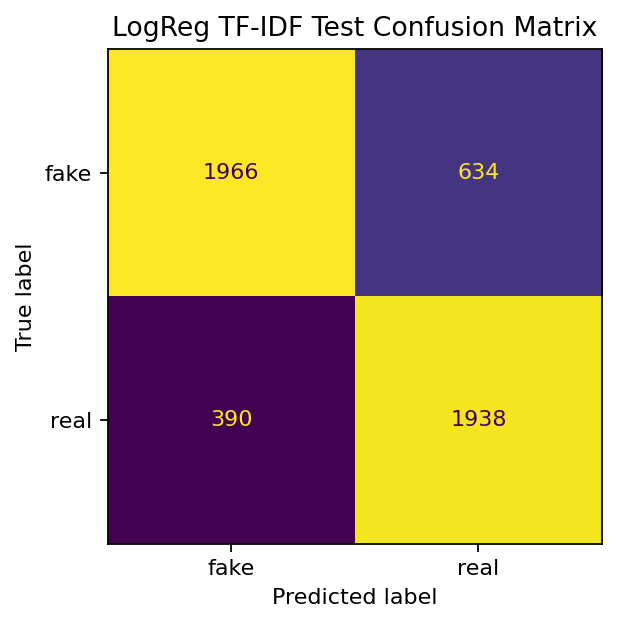

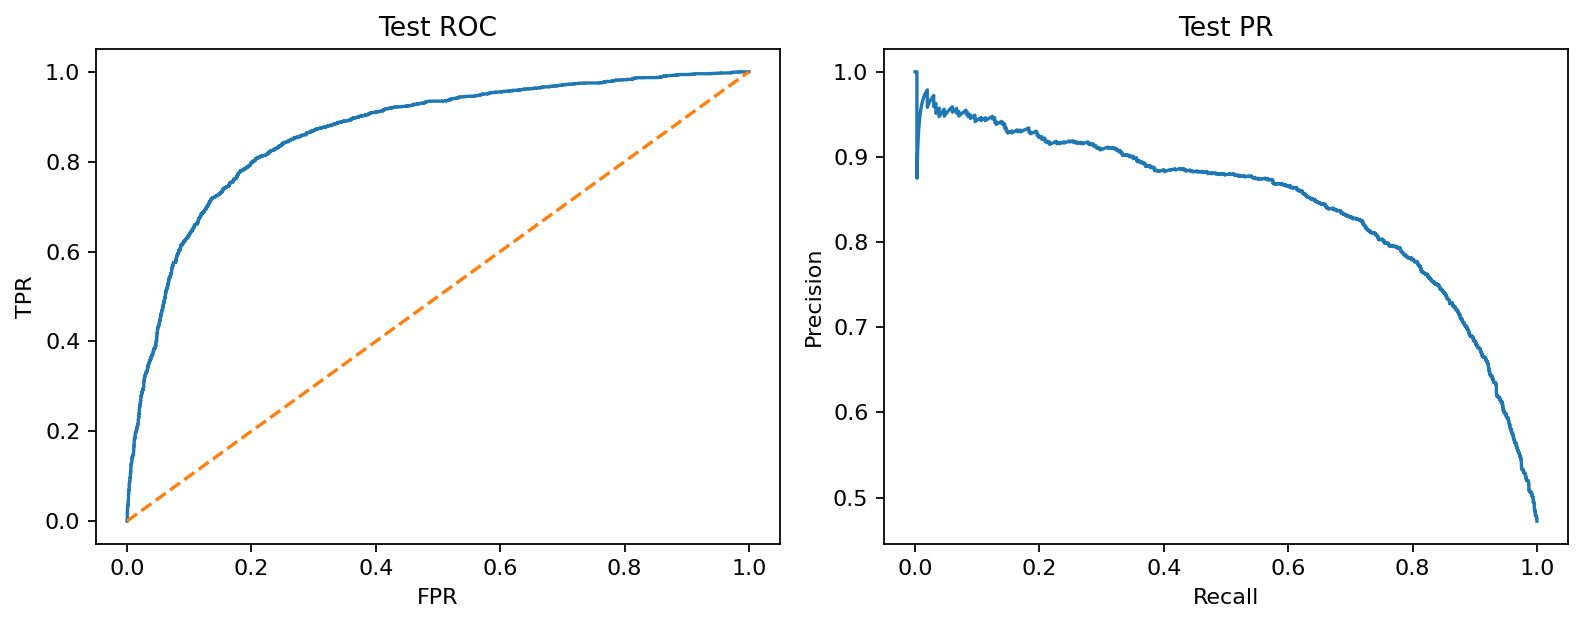


Summary: {'accuracy': 0.7922077922077922, 'macro_precision': 0.7939822088206017, 'macro_recall': 0.7943140364789849, 'macro_f1': 0.7922010838233599, 'roc_auc': 0.8659330392545599, 'pr_auc': 0.8445748744968774}
Artifacts saved to: C:/Users/admin/Documents/PSM1_LAVEN/Appendix_Evals/lr_examples


In [31]:
# Logistic Regression + TF-IDF: EXAMPLES + PLOTS on the SAME TEST TEXTS
import os, json, unicodedata, joblib, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, roc_curve, precision_recall_curve)

# --- Paths (same test texts as used for RoBERTa cell) ---
DATA_CSV      = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/Logistic Regression + TF-IDF/outputs_lr_tfidf/test_clean.csv"
PIPELINE_PATH = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/Logistic Regression + TF-IDF/outputs_lr_tfidf/lr_tfidf_negaware.joblib"
METRICS_JSON  = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/Logistic Regression + TF-IDF/outputs_lr_tfidf/lr_metrics.json"
OUT_DIR       = r"C:/Users/admin/Documents/PSM1_LAVEN/Appendix_Evals/lr_examples"
ENCODING      = "latin-1"
os.makedirs(OUT_DIR, exist_ok=True)

# --- helpers ---
def normalize_text_series(s: pd.Series) -> pd.Series:
    return s.astype(str).apply(lambda x: unicodedata.normalize("NFKC", x))

def ensure_columns(df: pd.DataFrame):
    need = {"claim_id","text","label"}
    miss = need - set(df.columns)
    if miss: raise ValueError(f"Missing columns: {miss}")

def map_labels(df: pd.DataFrame) -> np.ndarray:
    labmap = {"fake":0, "real":1}
    y = df["label"].astype(str).str.lower().map(labmap)
    if y.isna().any():
        raise ValueError(f"Unknown labels: {df.loc[y.isna(),'label'].unique().tolist()}")
    return y.astype(int).values

def evaluate_split(y_true, proba_real, thr):
    preds = (proba_real >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)
    p_pc, r_pc, f1_pc, _ = precision_recall_fscore_support(y_true, preds, average=None, zero_division=0)
    cm = confusion_matrix(y_true, preds).tolist()
    try: roc = float(roc_auc_score(y_true, proba_real))
    except: roc = float("nan")
    try: pr = float(average_precision_score(y_true, proba_real))
    except: pr = float("nan")
    return ({
        "threshold": float(thr),
        "accuracy": float(acc),
        "macro_precision": float(prec),
        "macro_recall": float(rec),
        "macro_f1": float(f1),
        "per_class_precision_[fake,real]": [float(x) for x in p_pc],
        "per_class_recall_[fake,real]": [float(x) for x in r_pc],
        "per_class_f1_[fake,real]": [float(x) for x in f1_pc],
        "confusion_matrix_[[tn,fp],[fn,tp]]": cm,
        "roc_auc": roc, "pr_auc": pr
    }, preds)

def save_confusion(y_true, proba, thr, title, path):
    preds = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["fake","real"])
    fig, ax = plt.subplots(figsize=(4,4), dpi=160)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout(); plt.savefig(path); plt.show(); plt.close(fig)

def save_roc_pr(y_true, proba, title_prefix, out_dir):
    try:
        fpr, tpr, _ = roc_curve(y_true, proba)
        prec, rec, _ = precision_recall_curve(y_true, proba)
    except Exception:
        return
    fig = plt.figure(figsize=(10,4), dpi=160)
    plt.subplot(1,2,1); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{title_prefix} ROC")
    plt.subplot(1,2,2); plt.plot(rec,prec)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{title_prefix} PR")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{title_prefix.lower()}_roc_pr.png")); plt.show(); plt.close(fig)

def shorten(s, n=220):
    s = str(s)
    return s if len(s) <= n else s[:n-1] + "…"

# --- load data ---
df = pd.read_csv(DATA_CSV, encoding=ENCODING)
ensure_columns(df)
if "text_clean" not in df.columns:
    df["text_clean"] = normalize_text_series(df["text"])
y_true = map_labels(df)

# --- load pipeline + threshold ---
pipe = joblib.load(PIPELINE_PATH)
thr = 0.5
if os.path.isfile(METRICS_JSON):
    m = json.load(open(METRICS_JSON, "r"))
    thr = float(m.get("best_threshold", thr))

# --- predict ---
if not hasattr(pipe, "predict_proba"):
    raise RuntimeError("LR pipeline has no predict_proba().")
proba = pipe.predict_proba(df["text_clean"])[:, 1]
metrics, preds = evaluate_split(y_true, proba, thr)

# --- results table + save ---
res = df[["claim_id","text","label"]].copy()
res["proba_real"] = proba
res["pred_label"] = np.where(proba >= thr, "real", "fake")
res["correct"]    = (res["pred_label"].str.lower() == res["label"].str.lower())
res["text_short"] = res["text"].apply(lambda s: shorten(s, 220))
res[["claim_id","text","label","proba_real","pred_label","correct"]].to_csv(
    os.path.join(OUT_DIR, "predictions_test.csv"), index=False, encoding="utf-8"
)

# --- show examples ---
pd.set_option("display.max_colwidth", 240)
print("=== 10 random examples ===")
display(res.sample(10, random_state=42)[["claim_id","text_short","label","pred_label","proba_real","correct"]])

print("\n=== 5 most confident REAL (highest proba_real) ===")
display(res.sort_values("proba_real", ascending=False).head(5)[
    ["claim_id","text_short","label","pred_label","proba_real","correct"]
])

print("\n=== 5 most confident FAKE (lowest proba_real) ===")
display(res.sort_values("proba_real", ascending=True).head(5)[
    ["claim_id","text_short","label","pred_label","proba_real","correct"]
])

mistakes = res[~res["correct"]]
if len(mistakes) > 0:
    print(f"\n=== Top 5 MISCLASSIFICATIONS (n={len(mistakes)}) ===")
    mistakes["conf_margin"] = np.where(mistakes["pred_label"]=="real",
                                       mistakes["proba_real"],
                                       1.0 - mistakes["proba_real"])
    display(mistakes.sort_values("conf_margin", ascending=False).head(5)[
        ["claim_id","text_short","label","pred_label","proba_real"]
    ])
else:
    print("\n=== No misclassifications in this split ===")

# --- plots + metrics json ---
save_confusion(y_true, proba, thr, "LogReg TF-IDF Test Confusion Matrix", os.path.join(OUT_DIR, "cm_test.png"))
save_roc_pr(y_true, proba, "Test", OUT_DIR)

with open(os.path.join(OUT_DIR, "metrics_test.json"), "w") as f:
    json.dump({"model_type":"logreg_tfidf", "threshold_used":thr, "test":metrics}, f, indent=2)

print("\nSummary:", {k: metrics[k] for k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})
print("Artifacts saved to:", OUT_DIR)
